In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

In [ ]:
# Load CIC-IDS dataset
df = pd.read_csv("/content/drive/MyDrive/CIC-IDS- 2017_dataset/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv")
print(df.shape)

(286467, 79)


In [ ]:
print(df.head())

    Destination Port   Flow Duration   Total Fwd Packets  \
0                 22         1266342                  41   
1                 22         1319353                  41   
2                 22             160                   1   
3                 22         1303488                  41   
4              35396              77                   1   

    Total Backward Packets  Total Length of Fwd Packets  \
0                       44                         2664   
1                       44                         2664   
2                        1                            0   
3                       42                         2728   
4                        2                            0   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                          6954                     456   
1                          6954                     456   
2                             0                       0   
3                          6634                 

In [ ]:
print(df.tail())

         Destination Port   Flow Duration   Total Fwd Packets  \
286462                443          196135                  49   
286463                443          378424                  49   
286464                443          161800                  70   
286465                443          142864                  50   
286466                443          186928                  46   

         Total Backward Packets  Total Length of Fwd Packets  \
286462                       57                         1331   
286463                       59                         1325   
286464                      103                         1427   
286465                       62                         1331   
286466                       57                         1319   

         Total Length of Bwd Packets   Fwd Packet Length Max  \
286462                        105841                     570   
286463                        104393                     570   
286464                        21

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286467 entries, 0 to 286466
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             286467 non-null  int64  
 1    Flow Duration                286467 non-null  int64  
 2    Total Fwd Packets            286467 non-null  int64  
 3    Total Backward Packets       286467 non-null  int64  
 4   Total Length of Fwd Packets   286467 non-null  int64  
 5    Total Length of Bwd Packets  286467 non-null  int64  
 6    Fwd Packet Length Max        286467 non-null  int64  
 7    Fwd Packet Length Min        286467 non-null  int64  
 8    Fwd Packet Length Mean       286467 non-null  float64
 9    Fwd Packet Length Std        286467 non-null  float64
 10  Bwd Packet Length Max         286467 non-null  int64  
 11   Bwd Packet Length Min        286467 non-null  int64  
 12   Bwd Packet Length Mean       286467 non-nul

In [ ]:
df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,286467.000000,2.864670e+05,286467.000000,286467.000000,286467.000000,2.864670e+05,286467.000000,286467.000000,286467.000000,286467.000000,...,286467.000000,286467.000000,2.864670e+05,2.864670e+05,2.864670e+05,2.864670e+05,2.864670e+05,2.864670e+05,2.864670e+05,2.864670e+05
mean,8044.876324,5.379331e+06,3.473283,3.520500,233.407667,2.707247e+03,81.033369,10.352013,24.138688,24.590994,...,1.728618,29.075328,3.409213e+04,2.294987e+04,7.785722e+04,2.171380e+04,1.602973e+06,6.120390e+04,1.647188e+06,1.536286e+06
std,15378.583442,2.192364e+07,19.515131,28.288916,1865.523600,5.097783e+04,327.768035,24.237795,78.381542,117.218043,...,14.897361,8.014607,4.659319e+05,2.623049e+05,7.342606e+05,4.223145e+05,8.682334e+06,1.217016e+06,8.882728e+06,8.561545e+06
min,0.000000,-1.300000e+01,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,80.000000,4.400000e+01,1.000000,1.000000,0.000000,6.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1110.000000,6.500000e+01,1.000000,1.000000,2.000000,6.000000e+00,2.000000,2.000000,2.000000,0.000000,...,0.000000,24.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,6881.000000,2.380600e+04,2.000000,2.000000,62.000000,1.150000e+02,37.000000,6.000000,34.000000,0.000000,...,1.000000,40.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,65389.000000,1.199999e+08,3119.000000,3635.000000,232349.000000,7.150819e+06,13929.000000,1472.000000,3412.938776,3541.466551,...,2056.000000,60.000000,1.100000e+08,7.050000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.050000e+07,1.200000e+08,1.200000e+08


In [ ]:
print(df.isnull().sum())

 Destination Port              0
 Flow Duration                 0
 Total Fwd Packets             0
 Total Backward Packets        0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
 Idle Std                      0
 Idle Max                      0
 Idle Min                      0
 Label                         0
Length: 79, dtype: int64


In [ ]:
# NaN values
df.isna().sum()

,0
Destination Port,0
Flow Duration,0
Total Fwd Packets,0
Total Backward Packets,0
Total Length of Fwd Packets,0
...,...
Idle Mean,0
Idle Std,0
Idle Max,0
Idle Min,0


In [ ]:
# infinite values
df.isin([np.inf, -np.inf]).sum()

,0
Destination Port,0
Flow Duration,0
Total Fwd Packets,0
Total Backward Packets,0
Total Length of Fwd Packets,0
...,...
Idle Mean,0
Idle Std,0
Idle Max,0
Idle Min,0


In [ ]:
#Handle infinite/NaN values
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

In [ ]:
df.shape

(286096, 79)

In [ ]:
data=df.drop_duplicates()
data

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,1266342,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,22,1319353,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,22,160,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,22,1303488,41,42,2728,6634,456,0,66.536585,110.129945,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,35396,77,1,2,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286462,443,196135,49,57,1331,105841,570,0,27.163265,108.067176,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
286463,443,378424,49,59,1325,104393,570,0,27.040816,108.095051,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
286464,443,161800,70,103,1427,215903,570,0,20.385714,90.746389,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
286465,443,142864,50,62,1331,110185,570,0,26.620000,107.027727,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
df.value_counts(' Label')

,count
Label,
PortScan,158804
BENIGN,127292


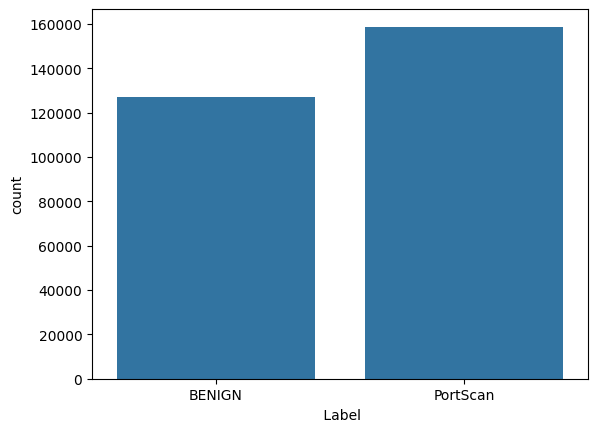

In [ ]:
sns.countplot(x=' Label', data=df)
plt.show()

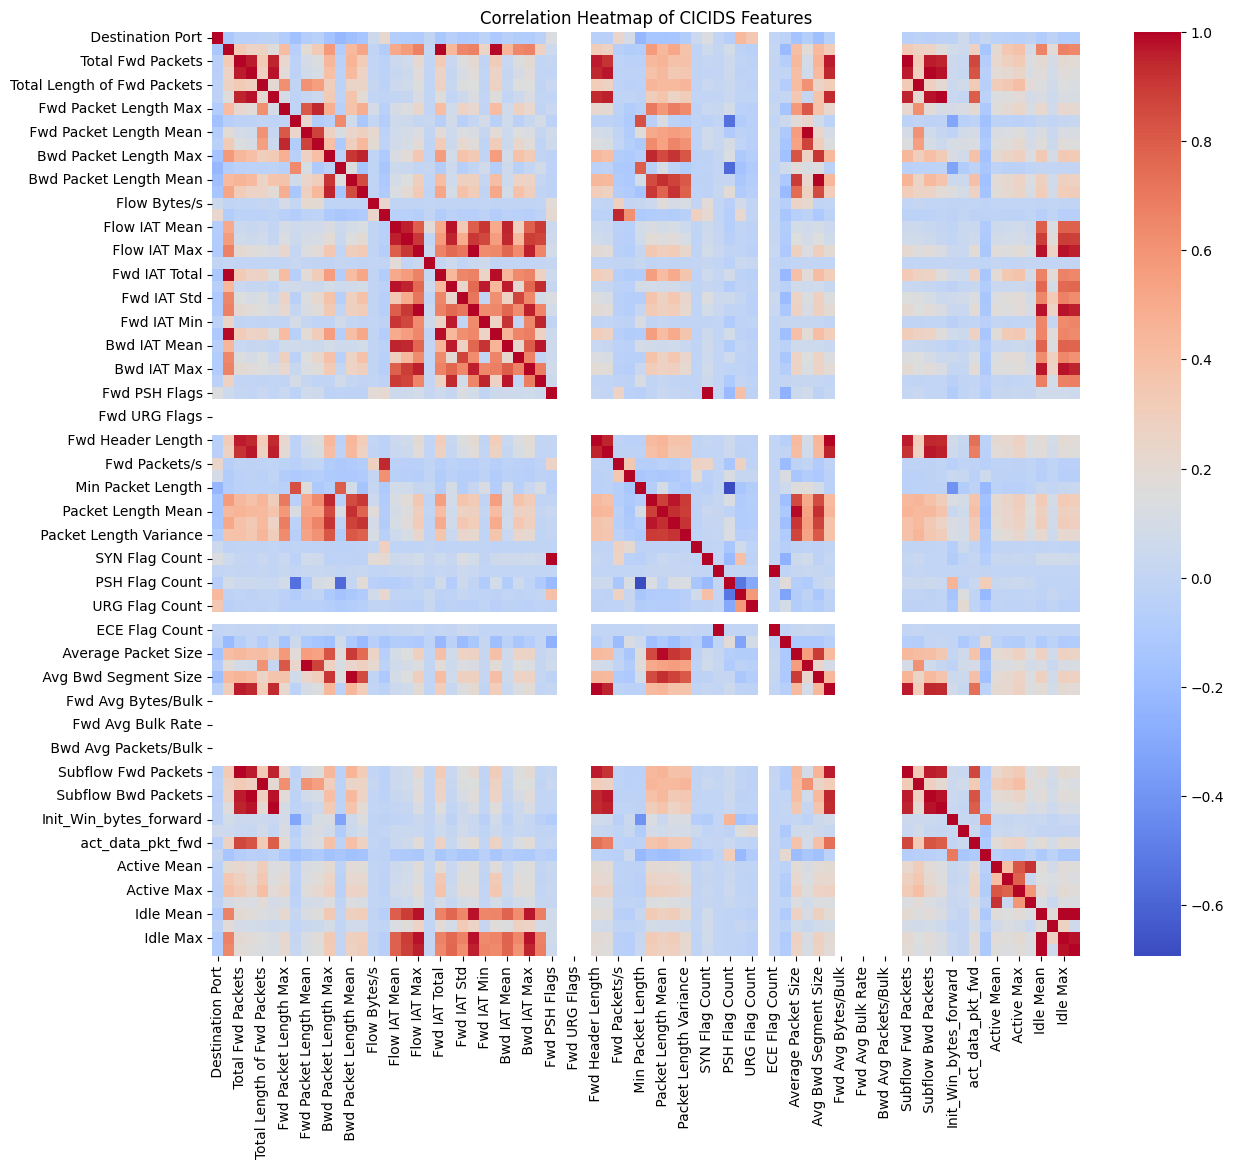

In [ ]:
# Correlation heatmap for all features in the dataset
data=df.drop(columns=[' Label'])
plt.figure(figsize=(14, 12))
sns.heatmap(data.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap of CICIDS Features')
plt.show()

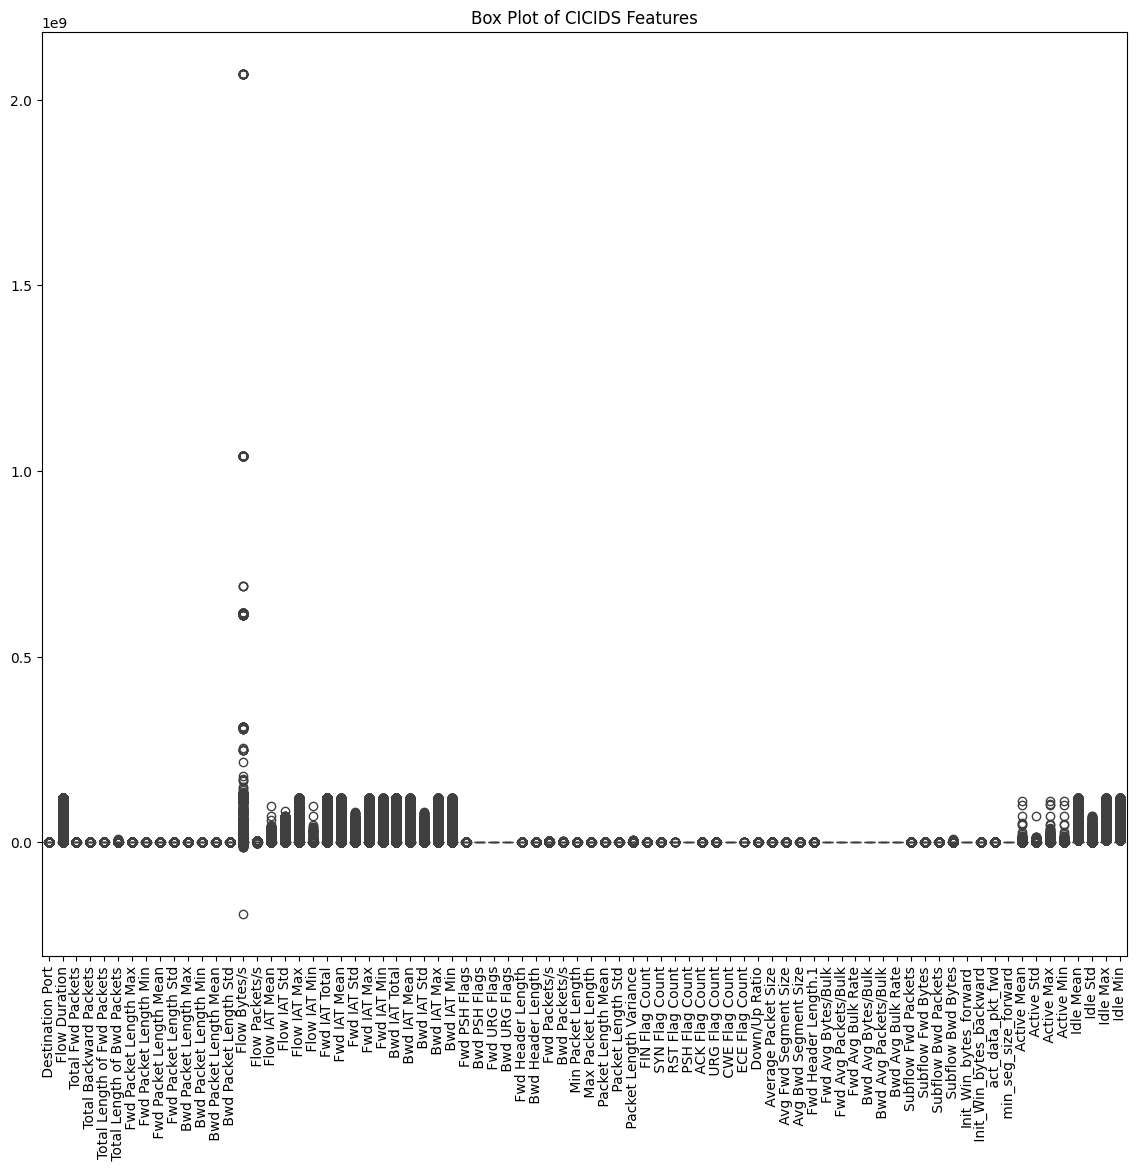

In [ ]:
# visualizing outliers using boxplot
plt.figure(figsize=(14, 12))
sns.boxplot(data=df)
plt.title('Box Plot of CICIDS Features')
plt.xticks(rotation=90)
plt.show()

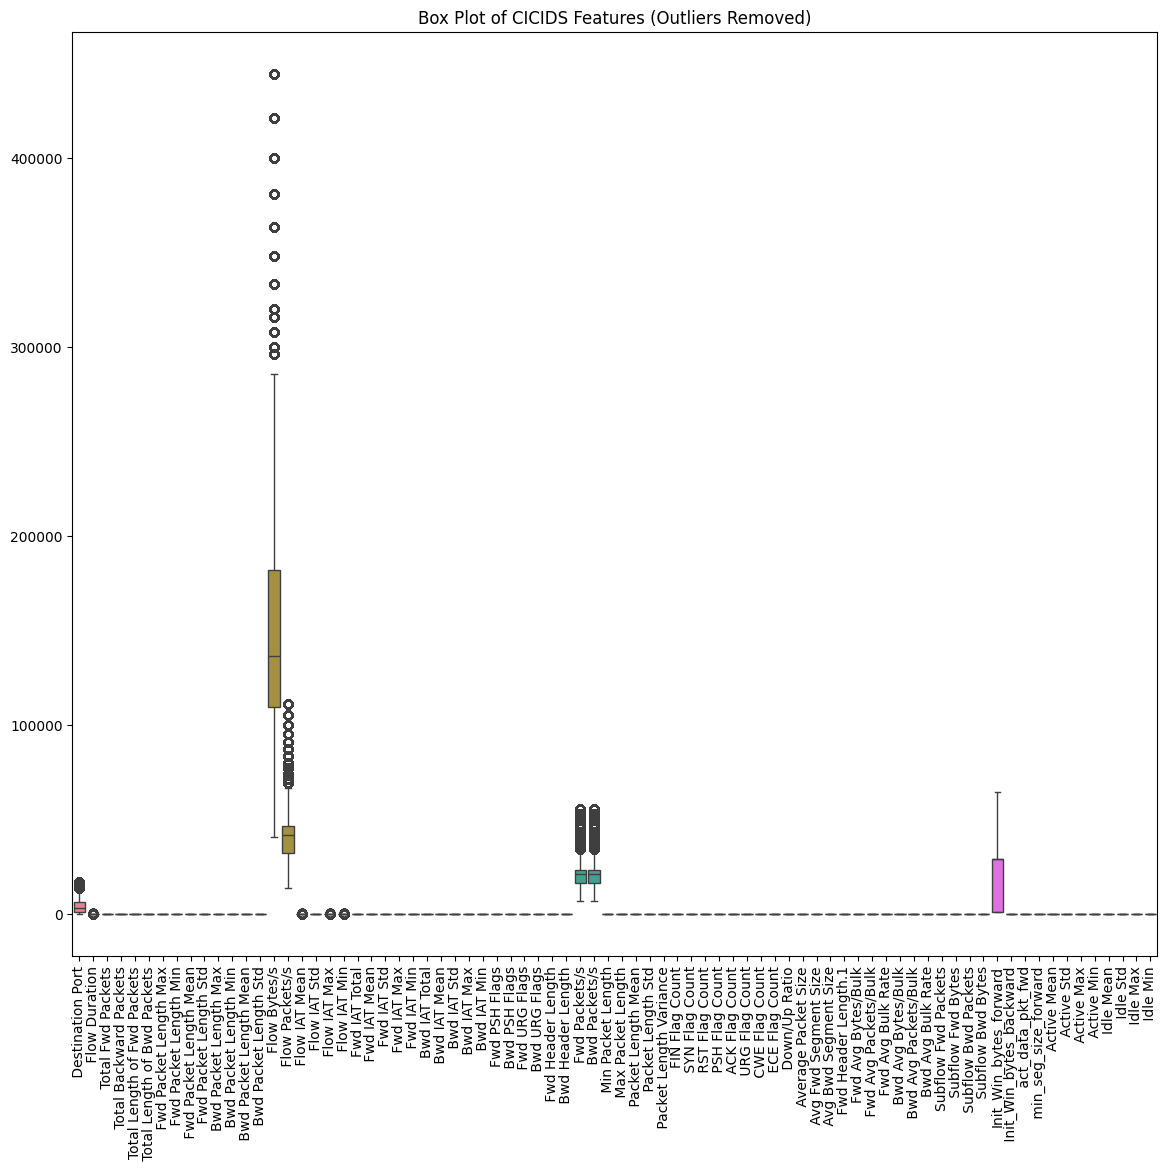

In [ ]:
# Handling outliers using IQR method
Q1 = df.select_dtypes(include=np.number).quantile(0.25)
Q3 = df.select_dtypes(include=np.number).quantile(0.75)
IQR = Q3 - Q1
df = df[~((df.select_dtypes(include=np.number) < (Q1 - 1.5 * IQR)) | (df.select_dtypes(include=np.number) > (Q3 + 1.5 * IQR))).any(axis=1)]

# Plot a boxplot
plt.figure(figsize=(14, 12))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.title('Box Plot of CICIDS Features (Outliers Removed)')
plt.xticks(rotation=90)
plt.show()

In [ ]:
print(df[' Label'].value_counts())

 Label
PortScan    158804
BENIGN      127292
Name: count, dtype: int64


In [ ]:
#Label encoding
encoder = LabelEncoder()
df[' Label'] = encoder.fit_transform(df[' Label'])

In [ ]:
X = df.drop(columns=[' Label'])
y = df[' Label']

In [ ]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
#Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

In [ ]:
#LogisticRegression
model = LogisticRegression(max_iter=500, class_weight='balanced')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy:{accuracy*100:.2f}%")
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy:99.93%
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     38214
           1       1.00      1.00      1.00     47615

    accuracy                           1.00     85829
   macro avg       1.00      1.00      1.00     85829
weighted avg       1.00      1.00      1.00     85829



In [ ]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy:{accuracy*100:.2f}%")
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy:99.99%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     38214
           1       1.00      1.00      1.00     47615

    accuracy                           1.00     85829
   macro avg       1.00      1.00      1.00     85829
weighted avg       1.00      1.00      1.00     85829



In [ ]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy:{accuracy*100:.2f}%")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy:99.99%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     38214
           1       1.00      1.00      1.00     47615

    accuracy                           1.00     85829
   macro avg       1.00      1.00      1.00     85829
weighted avg       1.00      1.00      1.00     85829



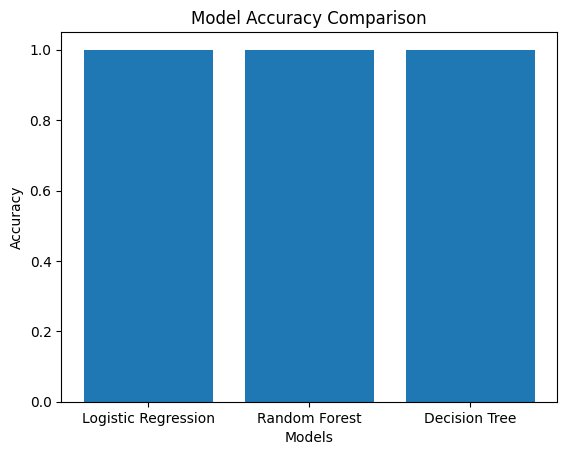

In [ ]:
#Model accuracy comparision plot
models = ['Logistic Regression', 'Random Forest', 'Decision Tree']
accuracy_scores = [accuracy, accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_dt)]
#plot
plt.bar(models, accuracy_scores)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.show()

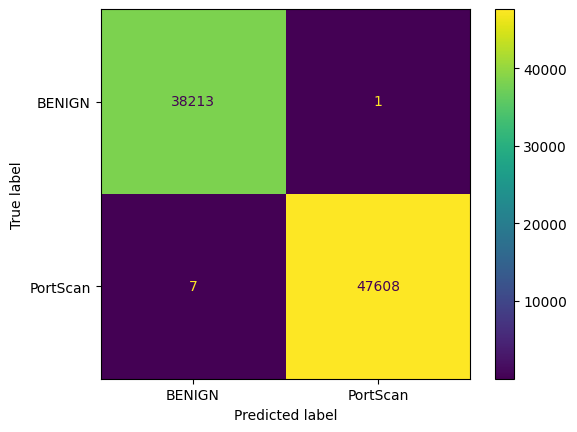

In [ ]:
# Visualization of confusion matrix
cm = confusion_matrix(y_test, y_pred_rf, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.classes_)
disp.plot()
plt.show()

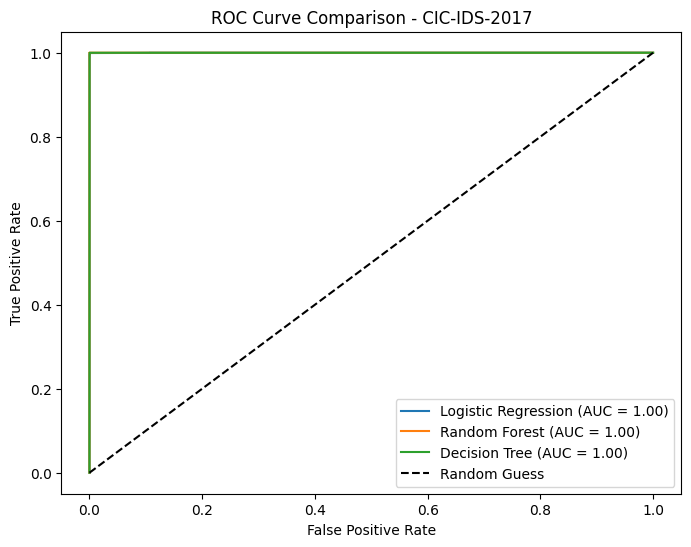

In [ ]:
# Plot ROC Curves
plt.figure(figsize=(8,6))

models_dict = {
    'Logistic Regression': model,
    'Random Forest': rf,
    'Decision Tree': dt
}

for name, model_obj in models_dict.items():
    y_score = model_obj.predict_proba(X_test)[:,1]  # probability for positive class

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Baseline (random guess)
plt.plot([0,1], [0,1], 'k--', label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - CIC-IDS-2017")
plt.legend(loc="lower right")
plt.show()